<div style="
           border-radius:20px;
           font-size:110%;
           font-family:cursive;
           letter-spacing:1px;
           font-family:cursive
           ">
<h1 style="text-align:center;">Insurance</h1>
<center>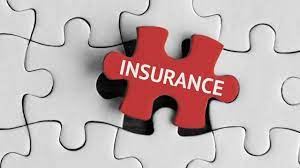</center>

<div style="color:white;
           display:fill;
           border-radius:30px;
           font-size:100%;
           font-family:cursive;
           letter-spacing:2px;
           background-color:pink;
           color:Purple;
           font-family:cursive
           ">
<h2 style="text-align:center;">Adding libraries</h2>
</div>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

<div style="color:white;
           display:fill;
           border-radius:30px;
           font-size:100%;
           font-family:cursive;
           letter-spacing:2px;
           background-color:pink;
           color:Purple;
           font-family:cursive
           ">
<h2 style="text-align:center;">Reading the dataset</h2>
</div>

In [ ]:
df = pd.read_csv('../input/insurance/insurance.csv')

<div style="color:white;
           display:fill;
           border-radius:30px;
           font-size:100%;
           font-family:cursive;
           letter-spacing:2px;
           background-color:pink;
           color:Purple;
           font-family:cursive
           ">
<h2 style="text-align:center;">Data Overview</h2>
</div>

In [ ]:
df.head(10)

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
df.shape

<div style="color:white;
           display:fill;
           border-radius:30px;
           font-size:100%;
           font-family:cursive;
           letter-spacing:2px;
           background-color:pink;
           color:Purple;
           font-family:cursive
           ">
<h2 style="text-align:center;">Checking the missing data</h2>
</div>

In [ ]:
df.isnull().sum().sort_values(ascending= False)

<div style="color:white;
           display:fill;
           border-radius:30px;
           font-size:100%;
           font-family:cursive;
           letter-spacing:2px;
           background-color:pink;
           color:Purple;
           font-family:cursive
           ">
<h2 style="text-align:center;">Distribution Plot</h2>
</div>

In [ ]:
sns.displot(df['age'])
plt.title('Age distribution')
plt.ylabel('density')
plt.xlabel('age')
plt.show()

In [ ]:
sns.displot(df['charges'])
plt.title('charges distribution')
plt.ylabel('density')
plt.xlabel('charges')
plt.show()

In [ ]:
sns.displot(df['bmi'])
plt.title('bmi distribution')
plt.ylabel('density')
plt.xlabel('bmi')
plt.show()

<div style="color:white;
           display:fill;
           border-radius:30px;
           font-size:100%;
           font-family:cursive;
           letter-spacing:2px;
           background-color:pink;
           color:Purple;
           font-family:cursive
           ">
<h2 style="text-align:center;">Count Plot</h2>
</div>

In [ ]:
df['region'].value_counts()

In [ ]:
fig = plt.figure(figsize = (6,4))
sns.countplot(df['region'])
plt.title('region distribution')
plt.show()

In [ ]:
df['sex'].value_counts()

In [ ]:
fig = plt.figure(figsize = (6,4))
sns.countplot(df['sex'])
plt.title('sex distribution')
plt.show()

In [ ]:
df['children'].value_counts()

In [ ]:
fig = plt.figure(figsize = (6,4))
sns.countplot(df['children'])
plt.title('children distribution')
plt.show()

<div style="color:white;
           display:fill;
           border-radius:30px;
           font-size:100%;
           font-family:cursive;
           letter-spacing:2px;
           background-color:pink;
           color:Purple;
           font-family:cursive
           ">
<h2 style="text-align:center;">Checking the correlation</h2>
</div>

In [ ]:
df['sex'] = pd.factorize(df['sex'])[0] + 1
df['region'] = pd.factorize(df['region'])[0] + 1
df['smoker'] = pd.factorize(df['smoker'])[0] + 1
corr = df.corr()
corr['charges'].sort_values(ascending=False)


<div style="color:white;
           display:fill;
           border-radius:30px;
           font-size:100%;
           font-family:cursive;
           letter-spacing:2px;
           background-color:pink;
           color:Purple;
           font-family:cursive
           ">
<h2 style="text-align:center;">Correlation Plot</h2>
</div>

In [ ]:
fig = plt.figure(figsize = (6, 4))
data_ploting = df.corr(method= 'pearson')
sns.heatmap(data_ploting, cmap='Reds', linecolor='black', linewidths= 2 )
plt.show()

<div style="color:white;
           display:fill;
           border-radius:30px;
           font-size:100%;
           font-family:cursive;
           letter-spacing:2px;
           background-color:pink;
           color:Purple;
           font-family:cursive
           ">
<h2 style="text-align:center;">Pair Plot</h2>
</div>

In [ ]:
fig = plt.figure(figsize = (6, 4))
sns.pairplot(df,diag_kind='kde');

<div style="color:white;
           display:fill;
           border-radius:30px;
           font-size:100%;
           font-family:cursive;
           letter-spacing:2px;
           background-color:pink;
           color:Purple;
           font-family:cursive
           ">
<h2 style="text-align:center;">Train and Test Split</h2>
</div>

In [ ]:
X = df.drop('charges', axis = 1)
y = df['charges']
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.3, random_state=101)

<div style="color:white;
           display:fill;
           border-radius:30px;
           font-size:100%;
           font-family:cursive;
           letter-spacing:2px;
           background-color:pink;
           color:Purple;
           font-family:cursive
           ">
<h2 style="text-align:center;">Scalling data</h2>
</div>

In [ ]:
scaler= StandardScaler()
scaler.fit(X_train)
X_train_scaled= scaler.transform(X_train)
X_test_scaled= scaler.transform(X_test)

<div style="color:white;
           display:fill;
           border-radius:30px;
           font-size:100%;
           font-family:cursive;
           letter-spacing:2px;
           background-color:pink;
           color:Purple;
           font-family:cursive
           ">
<h2 style="text-align:center;">Linear Regression Model</h2>
</div>

In [ ]:
linear_reg_model= LinearRegression()
linear_reg_model.fit(X_train_scaled, y_train)

In [ ]:
y_pred = linear_reg_model.predict(X_test_scaled)
y_pred = pd.DataFrame(y_pred)
MAE_li_reg= metrics.mean_absolute_error(y_test, y_pred)
MSE_li_reg = metrics.mean_squared_error(y_test, y_pred)
RMSE_li_reg =np.sqrt(MSE_li_reg)
pd.DataFrame([MAE_li_reg, MSE_li_reg, RMSE_li_reg], index=['MAE_li_reg', 'MSE_li_reg', 'RMSE_li_reg'], columns=['Metrics'])

In [ ]:
scores = cross_val_score(linear_reg_model, X_train_scaled, y_train, cv=5)
print(np.sqrt(scores))

In [ ]:
r2_score(y_test, linear_reg_model.predict(X_test_scaled))

<div style="color:white;
           display:fill;
           border-radius:30px;
           font-size:100%;
           font-family:cursive;
           letter-spacing:2px;
           background-color:pink;
           color:Purple;
           font-family:cursive
           ">
<h2 style="text-align:center;">Gradient Boosting Regressor Model</h2>
</div>

In [ ]:
Gradient_model = GradientBoostingRegressor()
Gradient_model.fit(X_train_scaled, y_train)

In [ ]:
y_pred = Gradient_model.predict(X_test_scaled)
y_pred = pd.DataFrame(y_pred)
MAE_gradient= metrics.mean_absolute_error(y_test, y_pred)
MSE_gradient = metrics.mean_squared_error(y_test, y_pred)
RMSE_gradient =np.sqrt(MSE_gradient)
pd.DataFrame([MAE_gradient, MSE_gradient, RMSE_gradient], index=['MAE_gradient', 'MSE_gradient', 'RMSE_gradient'], columns=['Metrics'])

In [ ]:
scores = cross_val_score(Gradient_model, X_train_scaled, y_train, cv=5)
print(np.sqrt(scores))

In [ ]:
r2_score(y_test, Gradient_model.predict(X_test_scaled))

<div style="color:white;
           display:fill;
           border-radius:30px;
           font-size:100%;
           font-family:cursive;
           letter-spacing:2px;
           background-color:pink;
           color:Purple;
           font-family:cursive
           ">
<h2 style="text-align:center;">XGB Regressor Model</h2>
</div> 

In [ ]:
XGB_model =XGBRegressor()
XGB_model.fit(X_train_scaled, y_train);

In [ ]:
y_pred = XGB_model.predict(X_test_scaled)
y_pred = pd.DataFrame(y_pred)
MAE_XGB= metrics.mean_absolute_error(y_test, y_pred)
MSE_XGB = metrics.mean_squared_error(y_test, y_pred)
RMSE_XGB =np.sqrt(MSE_XGB)
pd.DataFrame([MAE_XGB, MSE_XGB, RMSE_XGB], index=['MAE_XGB', 'MSE_XGB', 'RMSE_XGB'], columns=['Metrics'])

In [ ]:
scores = cross_val_score(XGB_model, X_train_scaled, y_train, cv=5)
print(np.sqrt(scores))

In [ ]:
r2_score(y_test, XGB_model.predict(X_test_scaled))

<div style="color:white;
           display:fill;
           border-radius:30px;
           font-size:100%;
           font-family:cursive;
           letter-spacing:2px;
           background-color:pink;
           color:Purple;
           font-family:cursive
           ">
<h2 style="text-align:center;">Decision Tree Regressor Model</h2>
</div> 

In [ ]:
tree_reg_model =DecisionTreeRegressor()
tree_reg_model.fit(X_train_scaled, y_train);

In [ ]:
y_pred = tree_reg_model.predict(X_test_scaled)
y_pred = pd.DataFrame(y_pred)
MAE_tree_reg= metrics.mean_absolute_error(y_test, y_pred)
MSE_tree_reg = metrics.mean_squared_error(y_test, y_pred)
RMSE_tree_reg =np.sqrt(MSE_tree_reg)
pd.DataFrame([MAE_tree_reg, MSE_tree_reg, RMSE_tree_reg], index=['MAE_tree_reg', 'MSE_tree_reg', 'RMSE_tree_reg'], columns=['Metrics'])

In [ ]:
scores = cross_val_score(tree_reg_model, X_train_scaled, y_train, cv=5)
print(np.sqrt(scores))

In [ ]:
r2_score(y_test, tree_reg_model.predict(X_test_scaled))

<div style="color:white;
           display:fill;
           border-radius:30px;
           font-size:100%;
           font-family:cursive;
           letter-spacing:2px;
           background-color:pink;
           color:Purple;
           font-family:cursive
           ">
<h2 style="text-align:center;">Random Forest Regressor Model</h2>
</div> 

In [ ]:
forest_reg_model =RandomForestRegressor()
forest_reg_model.fit(X_train_scaled, y_train);

In [ ]:
y_pred = forest_reg_model.predict(X_test_scaled)
y_pred = pd.DataFrame(y_pred)
MAE_forest_reg= metrics.mean_absolute_error(y_test, y_pred)
MSE_forest_reg = metrics.mean_squared_error(y_test, y_pred)
RMSE_forest_reg =np.sqrt(MSE_forest_reg)
pd.DataFrame([MAE_forest_reg, MSE_forest_reg, RMSE_forest_reg], index=['MAE_forest_reg', 'MSE_forest_reg', 'RMSE_forest_reg'], columns=['Metrics'])

In [ ]:
scores = cross_val_score(forest_reg_model, X_train_scaled, y_train, cv=5)
print(np.sqrt(scores))

In [ ]:
r2_score(y_test, forest_reg_model.predict(X_test_scaled))